In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
import numpy
from collision import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix

In [2]:
rng = numpy.random.default_rng()

In [3]:
multiplier = 1

In [4]:
mean_spacing = 1000 * multiplier
mean_x = 1
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

In [5]:
abar = (np.pi * 2 ** (-3/2) / math.gamma(5/4) / math.gamma(1/2)) ** 2
G = np.pi * (abar ** 2 - 1 / 3)

In [84]:
energy_dict = {}

lower = 0
upper = 100

for mean_spacing in upper/np.arange(500, 50, -10):
    mean_x = 1
    mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

    num = []
    for i in range(10000):
        num_resonances = 1500
        rng = np.random.default_rng()
        uniform_dist = rng.uniform(0, 1, num_resonances - 1)
        # transform uniform into a Wigner-Dyson distribution
        nearest_neighbor = mean_spacing * np.sqrt(-4 / np.pi * np.log(1 - uniform_dist))
        # generate energies
        energy_GOE_mat = np.zeros(num_resonances)
        energy_GOE_mat[0] = -np.sum(nearest_neighbor) / 2
        for i in range(num_resonances - 1):
            energy_GOE_mat[i + 1] = energy_GOE_mat[i] + nearest_neighbor[i]

        in_range = (energy_GOE_mat >= lower) & (energy_GOE_mat <= upper)
        num.append(in_range.sum())
        

    energy_dict[mean_spacing.item()] = num

import pickle 

with open("statistics.pkl", "wb") as f:
    pickle.dump(energy_dict, f)


In [85]:
print(energy_dict.keys())
plt.hist(energy_dict[5.2631578947368425])

dict_keys([0.2, 0.20408163265306123, 0.20833333333333334, 0.2127659574468085, 0.21739130434782608, 0.2222222222222222, 0.22727272727272727, 0.23255813953488372, 0.23809523809523808, 0.24390243902439024, 0.25, 0.2564102564102564, 0.2631578947368421, 0.2702702702702703, 0.2777777777777778, 0.2857142857142857, 0.29411764705882354, 0.30303030303030304, 0.3125, 0.3225806451612903, 0.3333333333333333, 0.3448275862068966, 0.35714285714285715, 0.37037037037037035, 0.38461538461538464, 0.4, 0.4166666666666667, 0.43478260869565216, 0.45454545454545453, 0.47619047619047616, 0.5, 0.5263157894736842, 0.5555555555555556, 0.5882352941176471, 0.625, 0.6666666666666666, 0.7142857142857143, 0.7692307692307693, 0.8333333333333334, 0.9090909090909091, 1.0, 1.1111111111111112, 1.25, 1.4285714285714286, 1.6666666666666667])


KeyError: 5.2631578947368425

In [86]:
spacings = []
means = []
stds = []
for mean_spacing in energy_dict:
    spacings.append(mean_spacing)
    nums = np.array(energy_dict[mean_spacing])
    means.append(np.mean(nums))
    stds.append(np.std(nums))

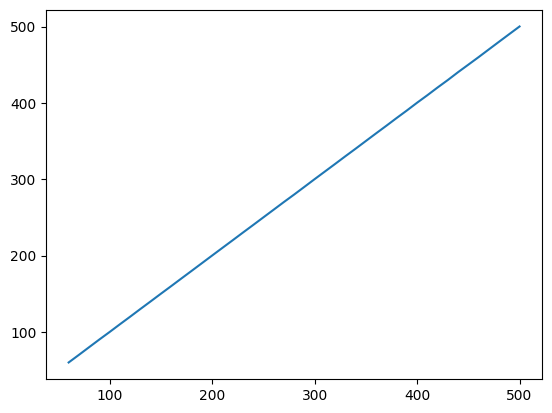

LinregressResult(slope=np.float64(1.0001525520421606), intercept=np.float64(-0.03954346069377834), rvalue=np.float64(0.9999998714151955), pvalue=np.float64(2.525822934341031e-143), stderr=np.float64(7.734671683678332e-05), intercept_stderr=np.float64(0.02387329522173093))


In [87]:
import scipy as sc
plt.plot(100/np.array(spacings), means)
plt.show()
res = sc.stats.linregress(100/np.array(spacings), means)
print(res)

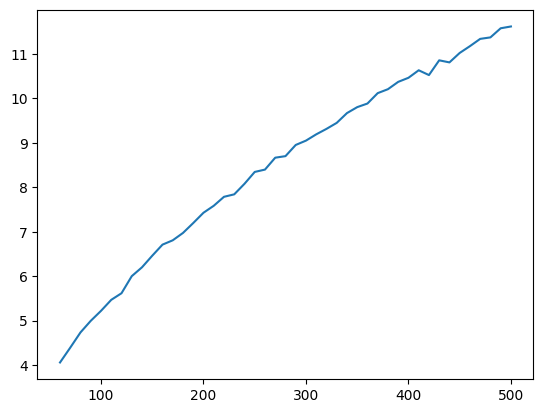

LinregressResult(slope=np.float64(0.5187525452549868), intercept=np.float64(0.06093335773666375), rvalue=np.float64(0.9996641747718434), pvalue=np.float64(7.325440518854596e-70), stderr=np.float64(0.002050723350763917), intercept_stderr=np.float64(0.03431516506128374))


In [89]:
plt.plot(100/np.array(spacings), np.array(stds))
# plt.plot(np.sqrt(100/np.array(spacings)), 0.5228115038431126 * np.sqrt(100/np.array(spacings)))
# plt.plot(np.sqrt(100/np.array(spacings)), 0.5*np.sqrt(100/np.array(spacings)))
plt.show()
res = sc.stats.linregress(np.sqrt(100/np.array(spacings)), stds)
print(res)

In [75]:
from statistics import linear_regression
slope, intercept = linear_regression(np.sqrt(100/np.array(spacings)), np.array(stds), proportional=True)
print(slope, intercept)

0.5228115038431126 0.0


In [56]:
1/0.5182458610367783

1.9295860810146117

In [15]:
np.sqrt(10) / np.std(num)

np.float64(1.8640624077076515)

In [17]:
np.sqrt(3)

np.float64(1.7320508075688772)

In [80]:
d = 0.06729858526586742

print(92.8/7.1)

num = 1/d
print(num)

print(np.sqrt(num) * 0.5)

print(np.sqrt(num) * 0.35)


13.070422535211268
14.859153369263785
1.9273786193469995
1.3491650335428995
